# BLACK FRIDAY SALES PREDICTION (REGRESSION PROBLEM)

## 1. Problem Definition

> This project is based on a real-world retail dataset capturing Black Friday sales transactions from a retail store. The goal is to build a regression model capable of predicting the purchase amount for a given transaction, based on customer demographics and product information.

## 2. Data

The training and test datasets were sourced from Kaggle. You can view and download the original CSV files at the following links:
* Train dataset: https://www.kaggle.com/code/midouazerty/black-friday-sales-prediction/input?select=train.csv
* Test dataset: https://github.com/sagnikghoshcr7/Black-Friday-Sales-Prediction/blob/master/test.csv

These datasets are part of the Black Friday Sales Prediction project:
* https://www.kaggle.com/code/midouazerty/black-friday-sales-prediction/notebook

## 3. Evaluation

> A model will be considered successful if it achieves an R² score of 0.75 or higher on the test set.


## 4. Features

**Data dictionary**

1. User_ID: Unique ID of the user. There are a total of 5891 users in the dataset.
2. Product_ID: Unique ID of the product. There are a total of 3623 products in the dataset.
3. Gender: indicates the gender of the person making the transaction.
4. Age: indicates the age group of the person making the transaction.
5. Occupation: shows the occupation of the user, already labeled with numbers 0 to 20.
6. City_Category: User's living city category. Cities are categorized into 3 different categories 'A', 'B' and 'C'.
7. Stay_In_Current_City_Years: Indicates how long the users has lived in this city.
8. Marital_Status: is 0 if the user is not married and 1 otherwise.
9. Product_Category_1 to _3: Category of the product. All 3 are already labeled with numbers.
10. Purchase: Purchase amount.

# Data Loading

In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder 
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.linear_model import LinearRegression 
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("train.csv")
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969
...,...,...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,NaN,NaN,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,NaN,NaN,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,NaN,NaN,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,NaN,NaN,365


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  str    
 2   Gender                      550068 non-null  str    
 3   Age                         550068 non-null  str    
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  str    
 6   Stay_In_Current_City_Years  550068 non-null  str    
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), str(5)
memory usage: 50.4 MB


In [4]:
df.describe()

,User_ID,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
count,5.500680e+05,550068.000000,550068.000000,550068.000000,376430.000000,166821.000000,550068.000000
mean,1.003029e+06,8.076707,0.409653,5.404270,9.842329,12.668243,9263.968713
std,1.727592e+03,6.522660,0.491770,3.936211,5.086590,4.125338,5023.065394
min,1.000001e+06,0.000000,0.000000,1.000000,2.000000,3.000000,12.000000
25%,1.001516e+06,2.000000,0.000000,1.000000,5.000000,9.000000,5823.000000
50%,1.003077e+06,7.000000,0.000000,5.000000,9.000000,14.000000,8047.000000
75%,1.004478e+06,14.000000,1.000000,8.000000,15.000000,16.000000,12054.000000
max,1.006040e+06,20.000000,1.000000,20.000000,18.000000,18.000000,23961.000000


In [5]:
df.isna().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Product_Category_3            383247
Purchase                           0
dtype: int64

# Data Cleaning

In [6]:
df = df.drop(["User_ID", "Product_ID"], axis=1)
df.head(10)

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,M,55+,16,C,4+,0,8,NaN,NaN,7969
5,M,26-35,15,A,3,0,1,2.0,NaN,15227
6,M,46-50,7,B,2,1,1,8.0,17.0,19215
7,M,46-50,7,B,2,1,1,15.0,NaN,15854
8,M,46-50,7,B,2,1,1,16.0,NaN,15686
9,M,26-35,20,A,1,1,8,NaN,NaN,7871


Given that the Product_Category_3 column has a negligible impact on the outcome — and, more critically, that over half of its values are missing (NaN) — I have decided to drop it.

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 10 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Gender                      550068 non-null  str    
 1   Age                         550068 non-null  str    
 2   Occupation                  550068 non-null  int64  
 3   City_Category               550068 non-null  str    
 4   Stay_In_Current_City_Years  550068 non-null  str    
 5   Marital_Status              550068 non-null  int64  
 6   Product_Category_1          550068 non-null  int64  
 7   Product_Category_2          376430 non-null  float64
 8   Product_Category_3          166821 non-null  float64
 9   Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(4), str(4)
memory usage: 42.0 MB


In [8]:
df["Product_Category_3"].isna().sum()

np.int64(383247)

In [9]:
df["Product_Category_3"].value_counts(dropna=False)

Product_Category_3
NaN     383247
16.0     32636
15.0     28013
14.0     18428
17.0     16702
5.0      16658
8.0      12562
9.0      11579
12.0      9246
13.0      5459
6.0       4890
18.0      4629
4.0       1875
11.0      1805
10.0      1726
3.0        613
Name: count, dtype: int64

In [10]:
df = df.drop(["Product_Category_3"], axis=1)
df.dtypes

Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Purchase                        int64
dtype: object

In [11]:
df.isna().sum()

Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Purchase                           0
dtype: int64

In [12]:
df["Product_Category_2"].value_counts(dropna=False)

Product_Category_2
NaN     173638
8.0      64088
14.0     55108
2.0      49217
16.0     43255
15.0     37855
5.0      26235
4.0      25677
6.0      16466
11.0     14134
17.0     13320
13.0     10531
9.0       5693
12.0      5528
10.0      3043
3.0       2884
18.0      2770
7.0        626
Name: count, dtype: int64

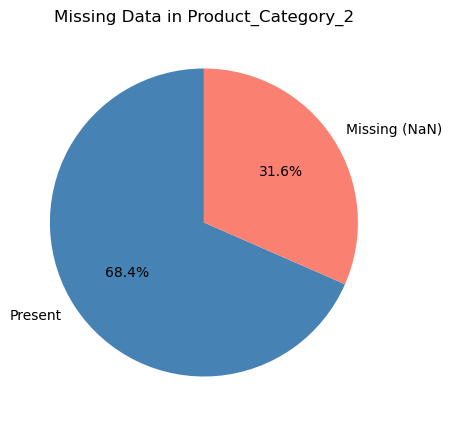

In [13]:
missing = df["Product_Category_2"].isnull().mean() * 100
present = 100 - missing

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    [present, missing],
    labels=['Present', 'Missing (NaN)'],
    colors=['steelblue', 'salmon'],
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title('Missing Data in Product_Category_2')
plt.show()

In [14]:
df["Product_Category_2"]

0          NaN
1          6.0
2          NaN
3         14.0
4          NaN
          ... 
550063     NaN
550064     NaN
550065     NaN
550066     NaN
550067     NaN
Name: Product_Category_2, Length: 550068, dtype: float64

In [15]:
df.isna().sum()

Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2            173638
Purchase                           0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(6390)

In [17]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Occupation,Marital_Status,Product_Category_1,Product_Category_2,Purchase
count,543678.000000,543678.000000,543678.000000,374007.000000,543678.000000
mean,8.089391,0.410550,5.398133,9.849698,9281.582440
std,6.525648,0.491934,3.944004,5.085093,5033.636881
min,0.000000,0.000000,1.000000,2.000000,12.000000
25%,2.000000,0.000000,1.000000,5.000000,5825.000000
50%,7.000000,0.000000,5.000000,9.000000,8054.000000
75%,14.000000,1.000000,8.000000,15.000000,12070.000000
max,20.000000,1.000000,20.000000,18.000000,23961.000000


In [19]:
df.dtypes

Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years        str
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Purchase                        int64
dtype: object

In [20]:
df["Stay_In_Current_City_Years"] = df["Stay_In_Current_City_Years"].str.replace("+", "").astype(int)
df.dtypes

Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years      int64
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
Purchase                        int64
dtype: object

# EDA

### Visualizing the gender distribution within the dataset

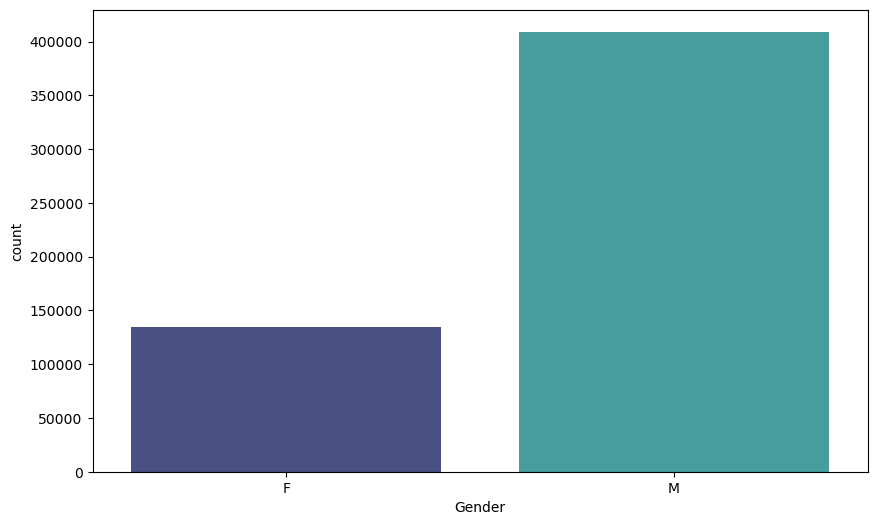

In [21]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x="Gender", hue="Gender", palette="mako", legend=False);

In [22]:
counts = df.Gender.value_counts()
counts

Gender
M    409103
F    134575
Name: count, dtype: int64

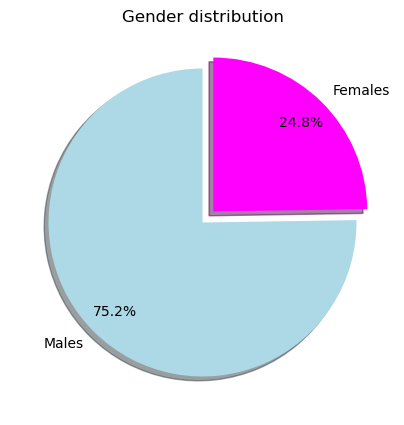

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    counts,
    labels=["Males", "Females"],
    colors=["lightblue", "magenta"],
    startangle=90,
    autopct="%1.1f%%",
    explode=(0, 0.1),
    shadow=True,
    pctdistance=0.81
)

ax.set_title("Gender distribution")
plt.show();

From this plot, we can deduce that the male gender count is higher than the female gender count.

### A comparative visualization of marital status distribution across genders

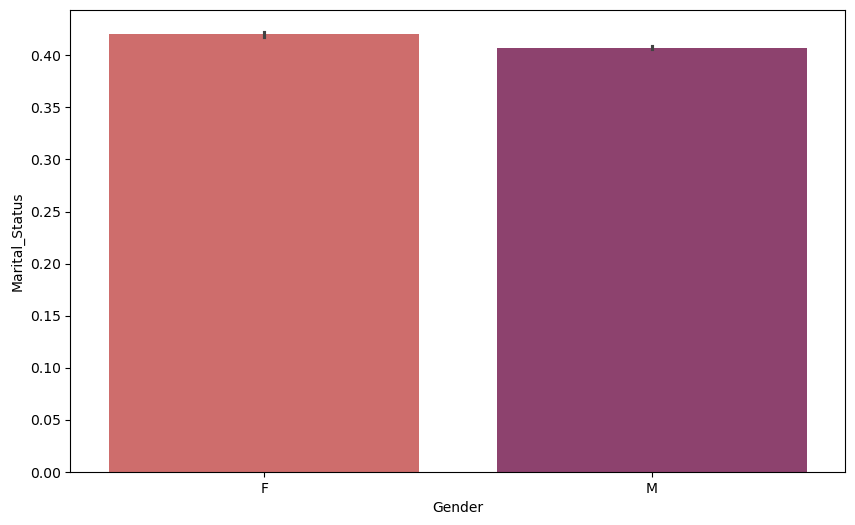

In [24]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Gender", y="Marital_Status", hue="Gender", palette="flare", legend=False);

In [25]:
pd.crosstab(df.Gender, df["Marital_Status"], normalize="index")

Marital_Status,0,1
Gender,,
F,0.579811,0.420189
M,0.592621,0.407379


Females show a slightly higher average marital status score than males, suggesting a marginally higher proportion of married female customers in the dataset.

### Visualizing purchase behavior across genders

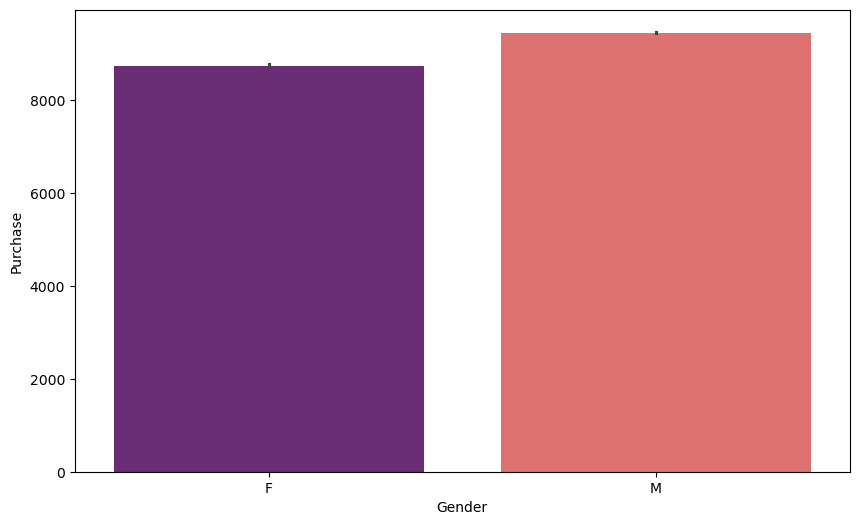

In [26]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x="Gender", y="Purchase", hue="Gender", palette="magma", legend=False);

In [27]:
df.groupby("Gender")["Purchase"].mean().round(2)

Gender
F    8746.93
M    9457.46
Name: Purchase, dtype: float64

Male customers tend to spend slightly more per transaction on average compared to female customers, though the difference is not dramatic.

### Visualizing purchase distribution across occupations

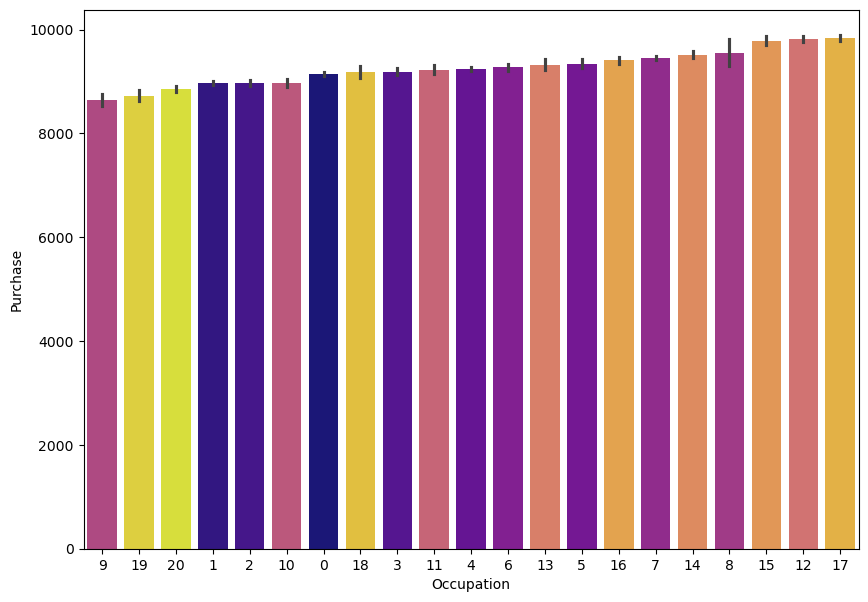

In [28]:
ascending_order = df.groupby("Occupation")["Purchase"].mean().sort_values().index
plt.figure(figsize=(10, 7))
sns.barplot(data=df, x="Occupation", y="Purchase", hue="Occupation",
            order=ascending_order, palette="plasma", legend=False);

Purchase amounts vary across occupations, with some occupations showing notably higher average spending. The chart is sorted in ascending order to highlight this variation more clearly.

### Visualizing purchase distribution across occupations by gender

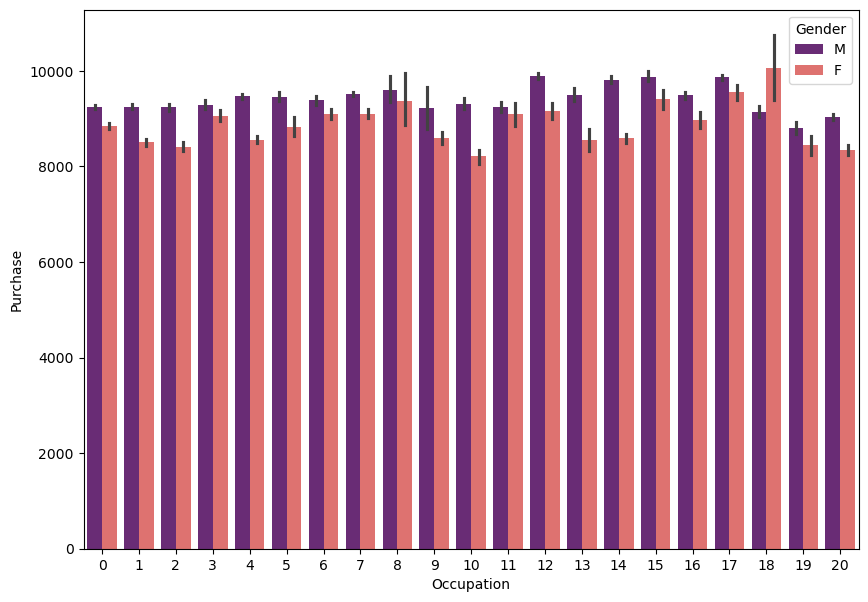

In [29]:
plt.figure(figsize=(10, 7))
sns.barplot(data=df, x="Occupation", y="Purchase", hue="Gender", palette="magma", legend=True);

When broken down by gender, the spending pattern across occupations remains relatively consistent — males tend to spend slightly more across most occupations, with no single occupation showing a strong gender-driven purchasing difference.

### Checking for outliers in the dataset

#### Analyzing purchase distribution

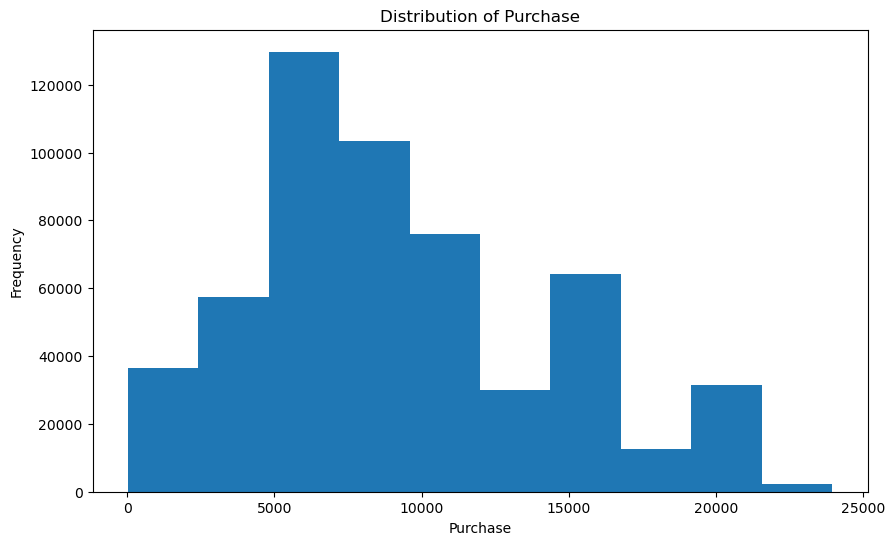

In [30]:
plt.figure(figsize=(10, 6))
df.Purchase.plot.hist()
plt.xlabel("Purchase")
plt.ylabel("Frequency")
plt.title("Distribution of Purchase")
plt.show()

The distribution of purchase amounts is right-skewed, with the majority of transactions falling between 5,000 and 15,000. A small number of high-value transactions pull the distribution to the right.

#### Analyzing purchase distribution in relation to gender

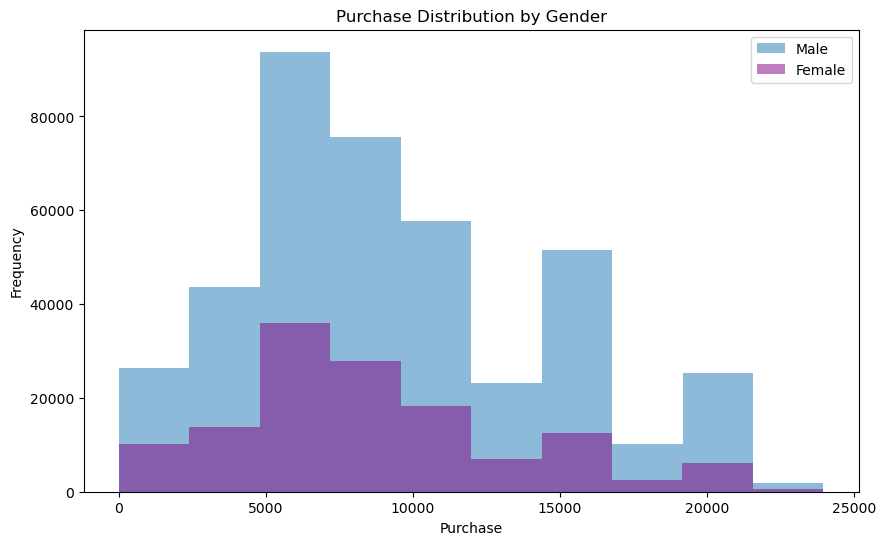

In [31]:
plt.figure(figsize=(10, 6))

df[df["Gender"] == "M"]["Purchase"].plot.hist(alpha=0.5, label="Male")
df[df["Gender"] == "F"]["Purchase"].plot.hist(alpha=0.5, label="Female", color="purple")

plt.xlabel("Purchase")
plt.ylabel("Frequency")
plt.title("Purchase Distribution by Gender")

plt.legend()
plt.show()

Both male and female purchase distributions follow a similar shape, confirming that gender alone does not strongly differentiate purchase behavior.

### Purchase distribution by gender — outlier analysis

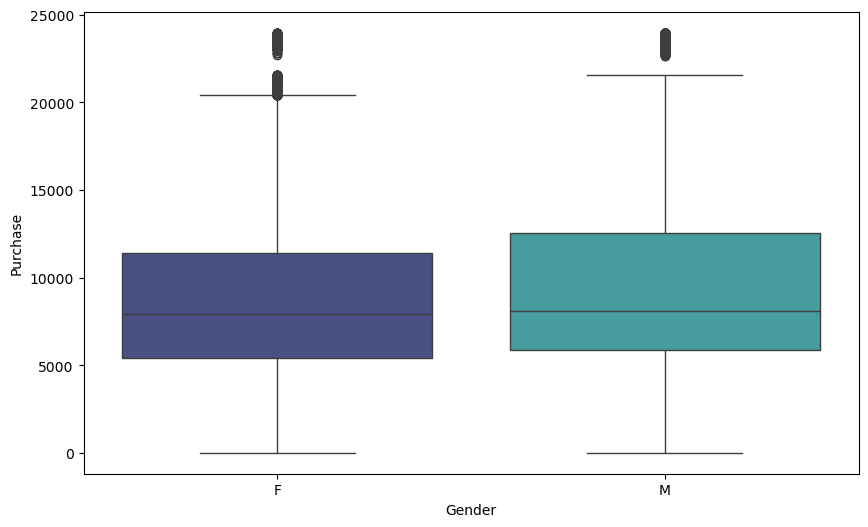

In [32]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Gender", y="Purchase", hue="Gender", palette="mako", legend=False);

The boxplot confirms that males have a slightly higher median purchase amount. Both distributions show a number of high-value outliers above 20,000.

### Purchase distribution across occupations — outlier analysis

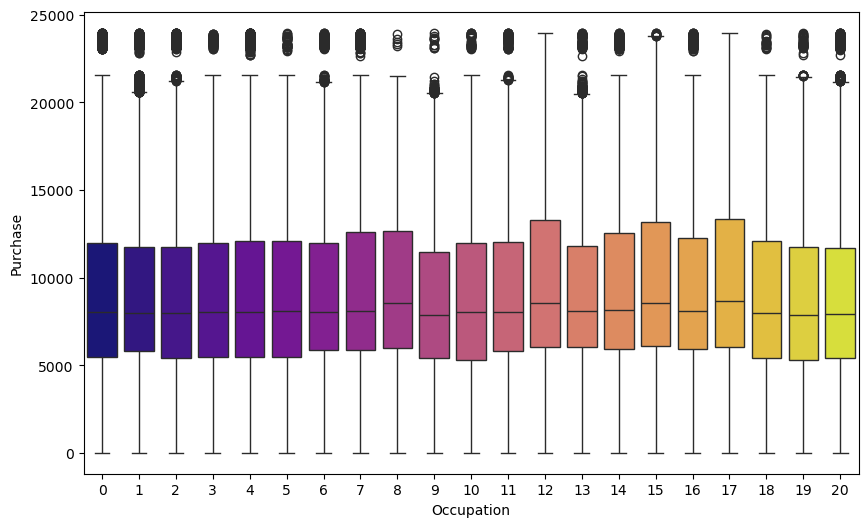

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Occupation", y="Purchase", hue="Occupation", palette="plasma", legend=False);

Purchase amounts vary across occupations, and outliers above 20,000 are present across nearly all occupation groups, confirming that high-value transactions are not isolated to specific professions.

### Purchase distribution across age groups — outlier analysis

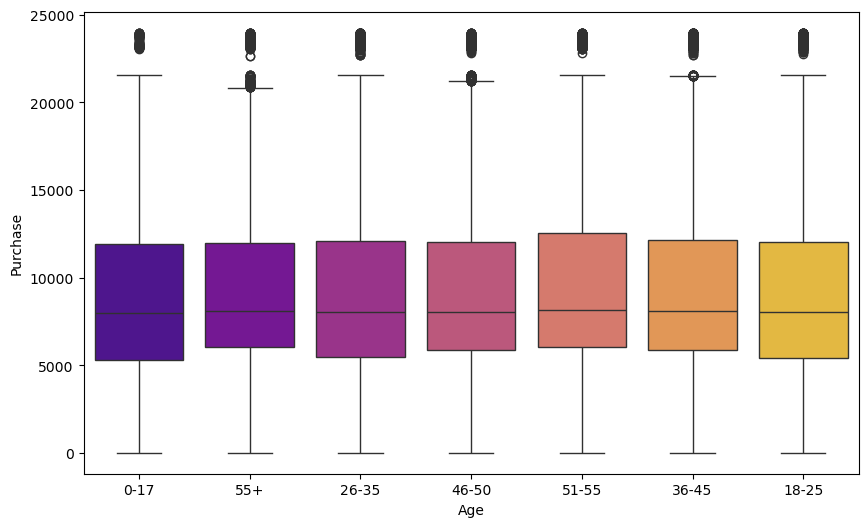

In [34]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Age", y="Purchase", hue="Age", palette="plasma", legend=False);

Purchase behavior appears relatively stable across age groups, with the 51–55 age group showing the highest volume of transactions. Outliers above 20,000 are present in all age groups.

### Purchase distribution across product categories — outlier analysis

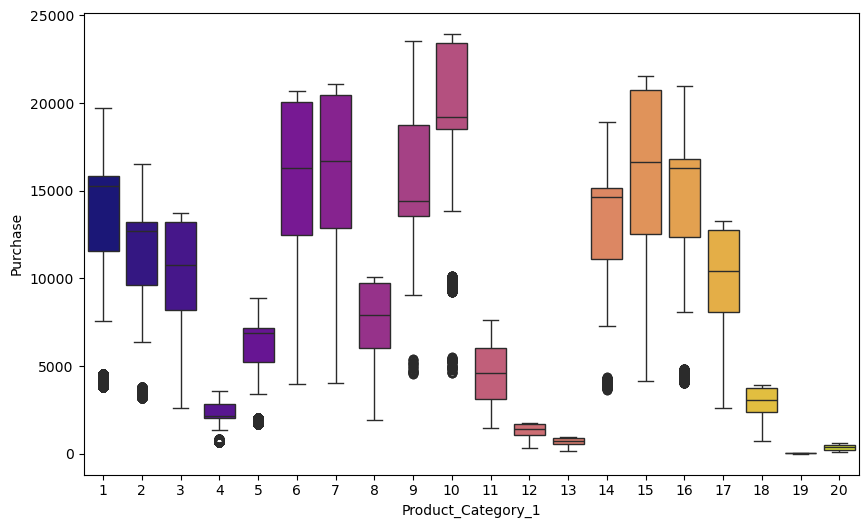

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x="Product_Category_1", y="Purchase", hue="Product_Category_1", 
            palette="plasma", legend=False);

Certain product categories, particularly lower-numbered ones are associated with significantly higher purchase amounts and a wider spread of values, suggesting these are premium or high-demand product categories.

## Data Preprocessing

### Imputing Missing Values

Since fewer than half of the values in the Product_Category_2 column are missing (NaN), median imputation has been applied. The missing values were filled with the column's median value and subsequently converted to integer type, as Product_Category_2 represents a discrete product category.

In [36]:
df["Product_Category_2"] = df["Product_Category_2"].fillna(df["Product_Category_2"].median()).astype(int)

In [37]:
df.info()

<class 'pandas.DataFrame'>
Index: 543678 entries, 0 to 550067
Data columns (total 9 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   Gender                      543678 non-null  str  
 1   Age                         543678 non-null  str  
 2   Occupation                  543678 non-null  int64
 3   City_Category               543678 non-null  str  
 4   Stay_In_Current_City_Years  543678 non-null  int64
 5   Marital_Status              543678 non-null  int64
 6   Product_Category_1          543678 non-null  int64
 7   Product_Category_2          543678 non-null  int64
 8   Purchase                    543678 non-null  int64
dtypes: int64(6), str(3)
memory usage: 41.5 MB


In [38]:
df.head()

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,F,0-17,10,A,2,0,3,9,8370
1,F,0-17,10,A,2,0,1,6,15200
2,F,0-17,10,A,2,0,12,9,1422
3,F,0-17,10,A,2,0,12,14,1057
4,M,55+,16,C,4,0,8,9,7969


In [39]:
df.tail()

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
550063,M,51-55,13,B,1,1,20,9,368
550064,F,26-35,1,C,3,0,20,9,371
550065,F,26-35,15,B,4,1,20,9,137
550066,F,55+,1,C,2,0,20,9,365
550067,F,46-50,0,B,4,1,20,9,490


In [40]:
df.dtypes

Gender                          str
Age                             str
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years    int64
Marital_Status                int64
Product_Category_1            int64
Product_Category_2            int64
Purchase                      int64
dtype: object

### LabelEncoder

In [41]:
le = LabelEncoder()
df.Age = le.fit_transform(df.Age)
df.dtypes

Gender                          str
Age                           int64
Occupation                    int64
City_Category                   str
Stay_In_Current_City_Years    int64
Marital_Status                int64
Product_Category_1            int64
Product_Category_2            int64
Purchase                      int64
dtype: object

In [42]:
df.head()

,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase
0,F,0,10,A,2,0,3,9,8370
1,F,0,10,A,2,0,1,6,15200
2,F,0,10,A,2,0,12,9,1422
3,F,0,10,A,2,0,12,14,1057
4,M,6,16,C,4,0,8,9,7969


### OneHotEncoder

In [43]:
cat_features = ["Gender", "City_Category"]
one_hot = OneHotEncoder(sparse_output=False, dtype=int)
encoded = one_hot.fit_transform(df[cat_features])
one_hot_cols = one_hot.get_feature_names_out(cat_features)
transformed_df = pd.DataFrame(encoded, columns=one_hot_cols, index=df.index)
df = df.drop(cat_features, axis=1)
df = pd.concat([df, transformed_df], axis=1)

In [44]:
df.head()

,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Purchase,Gender_F,Gender_M,City_Category_A,City_Category_B,City_Category_C
0,0,10,2,0,3,9,8370,1,0,1,0,0
1,0,10,2,0,1,6,15200,1,0,1,0,0
2,0,10,2,0,12,9,1422,1,0,1,0,0
3,0,10,2,0,12,14,1057,1,0,1,0,0
4,6,16,4,0,8,9,7969,0,1,0,0,1


In [45]:
df.info()

<class 'pandas.DataFrame'>
Index: 543678 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   Age                         543678 non-null  int64
 1   Occupation                  543678 non-null  int64
 2   Stay_In_Current_City_Years  543678 non-null  int64
 3   Marital_Status              543678 non-null  int64
 4   Product_Category_1          543678 non-null  int64
 5   Product_Category_2          543678 non-null  int64
 6   Purchase                    543678 non-null  int64
 7   Gender_F                    543678 non-null  int64
 8   Gender_M                    543678 non-null  int64
 9   City_Category_A             543678 non-null  int64
 10  City_Category_B             543678 non-null  int64
 11  City_Category_C             543678 non-null  int64
dtypes: int64(12)
memory usage: 53.9 MB


## Distribution plot

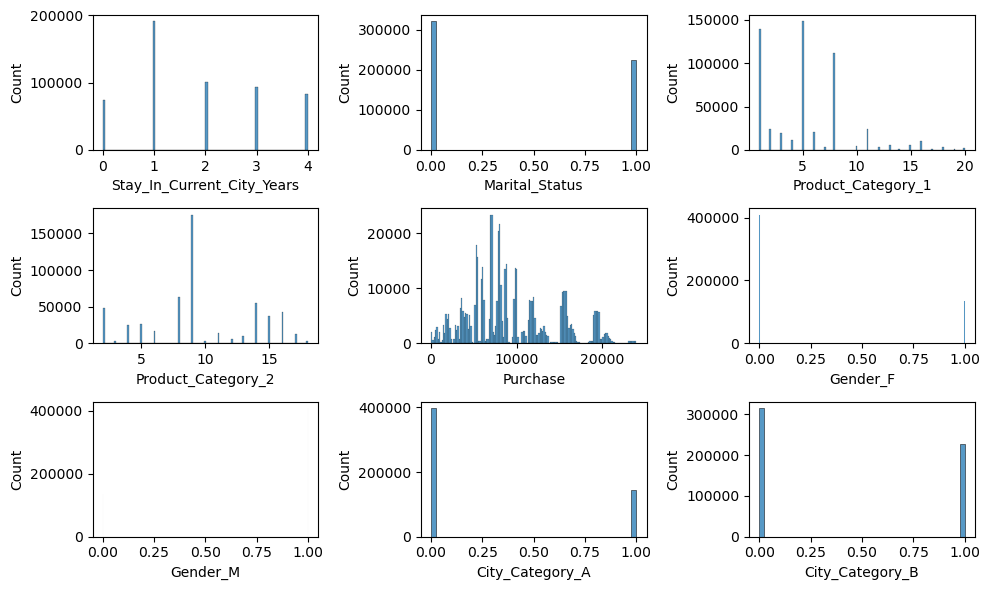

In [46]:
rows=3
cols=3
fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
col = df.columns 
index = 2 
for i in range(rows):
    for j in range(cols):
        sns.histplot(df[col[index]], ax=ax[i][j])
        index += 1
plt.tight_layout()

The distribution plots reveal that most features are relatively well-distributed, 
with the exception of Purchase, which shows a clear right skew — the majority of 
transactions are concentrated at lower values, with a long tail of high-value 
purchases pulling the distribution to the right. This skewness can negatively 
affect regression models that assume normally distributed residuals, and will 
be addressed through a log transformation in the next step.

## Log Transformation

I applied a log transformation to reduce the skewness of the data and bring its distribution closer to normality. If the original data follows a log-normal distribution, then the log-transformed data follows a normal or near normal distribution.

In [47]:
np.log(df["Purchase"])

0         9.032409
1         9.629051
2         7.259820
3         6.963190
4         8.983314
            ...   
550063    5.908083
550064    5.916202
550065    4.919981
550066    5.899897
550067    6.194405
Name: Purchase, Length: 543678, dtype: float64

In [48]:
df["Purchase"] = np.log(df["Purchase"])

## Distribution plot after Log Transformation

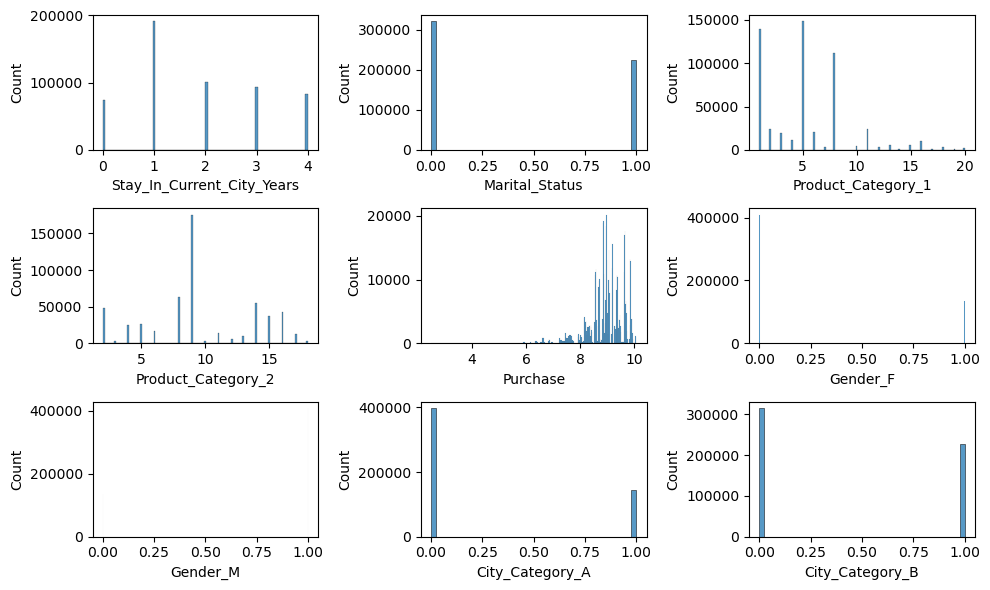

In [49]:
rows=3
cols=3
fig, ax = plt.subplots(nrows=rows, ncols=cols, figsize=(10, 6))
col = df.columns 
index = 2 
for i in range(rows):
    for j in range(cols):
        sns.histplot(df[col[index]], ax=ax[i][j])
        index += 1
plt.tight_layout()

After applying a log transformation to the Purchase column, the distribution 
becomes noticeably more symmetric and closer to a normal distribution. The long 
right tail observed previously has been compressed, and the bulk of values are 
now more evenly spread. This transformation stabilizes the variance across the 
target variable and generally leads to better regression model performance, as 
the model no longer needs to fit extreme purchase values on their original scale.

## Modeling

## Train Test Split

In [50]:
X = df.drop("Purchase", axis=1)
y = df["Purchase"]

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(434942, 11) (108736, 11) (434942,) (108736,)


In [52]:
X.head()

,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Gender_F,Gender_M,City_Category_A,City_Category_B,City_Category_C
0,0,10,2,0,3,9,1,0,1,0,0
1,0,10,2,0,1,6,1,0,1,0,0
2,0,10,2,0,12,9,1,0,1,0,0
3,0,10,2,0,12,14,1,0,1,0,0
4,6,16,4,0,8,9,0,1,0,0,1


In [53]:
y

0         9.032409
1         9.629051
2         7.259820
3         6.963190
4         8.983314
            ...   
550063    5.908083
550064    5.916202
550065    4.919981
550066    5.899897
550067    6.194405
Name: Purchase, Length: 543678, dtype: float64

## Scaling the data 

In [54]:
cols_to_scale = ["Age", "Occupation", "Product_Category_1", "Product_Category_2", 
                  "Stay_In_Current_City_Years"]
ss = StandardScaler()
X_train[cols_to_scale] = ss.fit_transform(X_train[cols_to_scale])
X_test[cols_to_scale] = ss.transform(X_test[cols_to_scale])

### LinearRegression

In [55]:
model = LinearRegression() 
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
y_preds_lr = model.predict(X_test)

In [57]:
cv_r2_lr = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
r2_lr = r2_score(y_test, y_preds_lr)
mae_lr = mean_absolute_error(y_test, y_preds_lr)
mse_lr = mean_squared_error(y_test, y_preds_lr)
rmse_lr = np.sqrt(mse_lr)
print(f"CV Mean R^2: {cv_r2_lr.mean():.4f} (+/-) {cv_r2_lr.std():.4f}")
print(f"r2_score: {r2_lr:.4f}")
print(f"mae score: {mae_lr:.4f}")
print(f"mse score: {mse_lr:.4f}")
print(f"rmse score: {rmse_lr:.4f}")

CV Mean R^2: 0.1918 (+/-) 0.0013
r2_score: 0.1866
mae score: 0.4569
mse score: 0.4416
rmse score: 0.6645


LinearRegression performs poorly on this dataset, achieving an R² of only 0.19 on both cross-validation and the test set. The high RMSE of 0.66 further confirms that a linear model is insufficient to capture the complex, non-linear relationships present in the data.

### DecisionTreeRegressor

In [58]:
model = DecisionTreeRegressor(max_depth=10, random_state=0)
model.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",0
,"max_leaf

A maximum depth of 10 was set as a starting point to prevent the tree from 
growing unconstrained on this large dataset (550K rows), which would result 
in excessive memory usage and training time. A fixed random state of 0 is 
used to ensure reproducibility across runs. All other parameters are left 
at their default values.

In [59]:
cv_r2_dt = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
X_preds_dt = model.predict(X_train)
y_preds_dt = model.predict(X_test)

In [60]:
rmse_train_dt = np.sqrt(mean_squared_error(y_train, X_preds_dt))
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_preds_dt))
r2_train_dt = model.score(X_train, y_train)
r2_test_dt = model.score(X_test, y_test)

In [61]:
print(f"CV Mean R^2 {cv_r2_dt.mean():.4f} (+/-) {cv_r2_dt.std():.4f}")
print(f"RMSE Training Data: {rmse_train_dt:.4f}")
print(f"RMSE Test Data: {rmse_test_dt:.4f}")
print('-'*50)
print(f"R^2 on train: {r2_train_dt:.4f}")
print(f"R^2 on test: {r2_test_dt:.4f}")

CV Mean R^2 0.7375 (+/-) 0.0035
RMSE Training Data: 0.3762
RMSE Test Data: 0.3792
--------------------------------------------------
R^2 on train: 0.7419
R^2 on test: 0.7352


The DecisionTreeRegressor significantly outperforms LinearRegression, 
achieving a cross-validated R² of 0.74 and a test R² of 0.74. The training 
R² of 0.74 and test R² of 0.74 are closely aligned, and the RMSE on both 
training (0.38) and test (0.38) data are nearly identical, indicating a 
well-balanced model with no significant overfitting.

### RandomForestRegressor

In [62]:
model = RandomForestRegressor() 
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [63]:
cv_r2_rf = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1)
X_preds_rf = model.predict(X_train)
y_preds_rf = model.predict(X_test)

In [64]:
rmse_train_rf = np.sqrt(mean_squared_error(y_train, X_preds_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_preds_rf))
r2_train_rf = model.score(X_train, y_train)
r2_test_rf = model.score(X_test, y_test)

In [65]:
print(f"CV Mean R^2: {cv_r2_rf.mean():.4f} (+/-) {cv_r2_rf.std():.4f}")
print(f"RMSE Training Data: {rmse_train_rf:.4f}")
print(f"RMSE Test Data: {rmse_test_rf:.4f}")
print('-'*50)
print(f"R^2 on train: {r2_train_rf:.4f}")
print(f"R^2 on test: {r2_test_rf:.4f}")

CV Mean R^2: 0.7335 (+/-) 0.0032
RMSE Training Data: 0.3252
RMSE Test Data: 0.3799
--------------------------------------------------
R^2 on train: 0.8071
R^2 on test: 0.7341


The RandomForestRegressor achieves a test R² of 0.74, comparable to the DecisionTree. However, a notable gap between the training R² (0.81) and test R² (0.74) suggests mild overfitting — the model has memorized some patterns in the training data that do not fully generalize. This will be addressed in the hyperparameter tuning phase.

## Hyperparameter Tuning

### LinearRegression

LinearRegression was excluded from hyperparameter tuning as it has very few tunable parameters and the default configuration already yields the best performance for this dataset.

### DecisionTreeRegressor

In [66]:
params_dt = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2', None]
}

dt = DecisionTreeRegressor(random_state=0) 
search_dt = RandomizedSearchCV(dt, params_dt, n_iter=20, cv=5, scoring="r2", random_state=0, n_jobs=-1)
search_dt.fit(X_train, y_train)

print(f"Best params {search_dt.best_params_}")
print(f"Best CV R^2: {search_dt.best_score_:.4f}")

best_dt = search_dt.best_estimator_
y_preds_dt = best_dt.predict(X_test)

r2_test_dt = r2_score(y_test, y_preds_dt)
rmse_test_dt = np.sqrt(mean_squared_error(y_test, y_preds_dt))

print(f"Test R^2: {r2_test_dt:.4f}")
print(f"Test RMSE: {rmse_test_dt:.4f}")


Best params {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 10}
Best CV R^2: 0.7378
Test R^2: 0.7358
Test RMSE: 0.3787


### RandomForestRegressor

In [67]:
params_rf = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2', None]   
}

rf = RandomForestRegressor(random_state=0)
search_rf = RandomizedSearchCV(rf, params_rf, n_iter=20, cv=5, scoring="r2", random_state=0, n_jobs=-1)
search_rf.fit(X_train, y_train)

print(f"Best params: {search_rf.best_params_}")
print(f"Best CV R^2: {search_rf.best_score_:.4f}")

best_rf = search_rf.best_estimator_
y_preds_rf = best_rf.predict(X_test)

r2_test_rf = r2_score(y_test, y_preds_rf)
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_preds_rf))

print(f"Test R^2: {r2_test_rf:.4f}")
print(f"Test RMSE: {rmse_test_rf:.4f}")

Best params: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': 20}
Best CV R^2: 0.7501
Test R^2: 0.7484
Test RMSE: 0.3696


# Evaluation

## Model Comparison

The table below summarizes the performance of all three models after 
hyperparameter tuning, comparing R² and RMSE scores on the test set. 
R² measures the proportion of variance in purchase amount explained by 
the model, while RMSE reflects the average prediction error on the 
log-transformed scale.

In [68]:
results = pd.DataFrame({
    "Model": ["LinearRegression", "DecisionTreeRegression", "RandomForestRegressor"],
    "R^2 after tuning": [
        r2_lr,
        r2_test_dt,
        r2_test_rf
    ],
    "RMSE after tuning": [
        rmse_lr,
        rmse_test_dt,
        rmse_test_rf
    ]
})
print(results)

                    Model  R^2 after tuning  RMSE after tuning
0        LinearRegression          0.186590           0.664524
1  DecisionTreeRegression          0.735776           0.378740
2   RandomForestRegressor          0.748406           0.369578


Note: LinearRegression was excluded from hyperparameter tuning as it has 
very few tunable parameters. The score reported in the table reflects its 
baseline performance.

The comparison above confirms that RandomForestRegressor is the best-performing 
model, achieving the highest R² of 0.748 and the lowest RMSE of 0.37 after 
hyperparameter tuning. DecisionTreeRegressor follows closely with an R² of 0.74, 
while LinearRegression proves inadequate for this dataset, with an R² of only 
0.19 — indicating that the relationship between features and purchase amount is 
inherently non-linear.

# Test dataset

## Data Loading

In [69]:
df_test = pd.read_csv("test.csv")
df_test.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
0,1000004,P00128942,M,46-50,7,B,2,1,1,11.0,NaN
1,1000009,P00113442,M,26-35,17,C,0,0,3,5.0,NaN
2,1000010,P00288442,F,36-45,1,B,4+,1,5,14.0,NaN
3,1000010,P00145342,F,36-45,1,B,4+,1,4,9.0,NaN
4,1000011,P00053842,F,26-35,1,C,1,0,4,5.0,12.0


In [70]:
df_test.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3
233594,1006036,P00118942,F,26-35,15,B,4+,1,8,NaN,NaN
233595,1006036,P00254642,F,26-35,15,B,4+,1,5,8.0,NaN
233596,1006036,P00031842,F,26-35,15,B,4+,1,1,5.0,12.0
233597,1006037,P00124742,F,46-50,1,C,4+,0,10,16.0,NaN
233598,1006039,P00316642,F,46-50,0,B,4+,1,4,5.0,NaN


In [71]:
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 11 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     233599 non-null  int64  
 1   Product_ID                  233599 non-null  str    
 2   Gender                      233599 non-null  str    
 3   Age                         233599 non-null  str    
 4   Occupation                  233599 non-null  int64  
 5   City_Category               233599 non-null  str    
 6   Stay_In_Current_City_Years  233599 non-null  str    
 7   Marital_Status              233599 non-null  int64  
 8   Product_Category_1          233599 non-null  int64  
 9   Product_Category_2          161255 non-null  float64
 10  Product_Category_3          71037 non-null   float64
dtypes: float64(2), int64(4), str(5)
memory usage: 19.6 MB


In [72]:
df_test.duplicated().sum()

np.int64(0)

In [73]:
df_test.isna().sum()

User_ID                            0
Product_ID                         0
Gender                             0
Age                                0
Occupation                         0
City_Category                      0
Stay_In_Current_City_Years         0
Marital_Status                     0
Product_Category_1                 0
Product_Category_2             72344
Product_Category_3            162562
dtype: int64

## Data Cleaning

In [74]:
df_test = df_test.drop(["User_ID", "Product_ID", "Product_Category_3"], axis=1)
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Gender                      233599 non-null  str    
 1   Age                         233599 non-null  str    
 2   Occupation                  233599 non-null  int64  
 3   City_Category               233599 non-null  str    
 4   Stay_In_Current_City_Years  233599 non-null  str    
 5   Marital_Status              233599 non-null  int64  
 6   Product_Category_1          233599 non-null  int64  
 7   Product_Category_2          161255 non-null  float64
dtypes: float64(1), int64(3), str(4)
memory usage: 14.3 MB


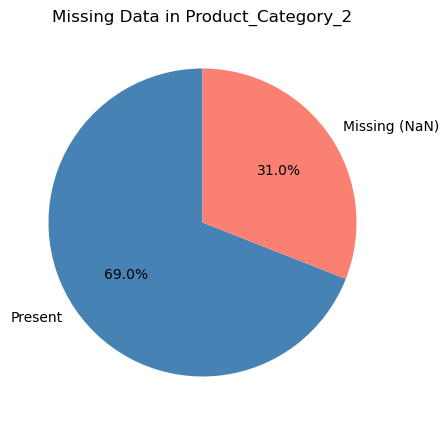

In [75]:
missing = df_test["Product_Category_2"].isnull().mean() * 100
present = 100 - missing

fig, ax = plt.subplots(figsize=(5, 5))

ax.pie(
    [present, missing],
    labels=['Present', 'Missing (NaN)'],
    colors=['steelblue', 'salmon'],
    autopct='%1.1f%%',
    startangle=90
)

ax.set_title('Missing Data in Product_Category_2')
plt.show()

Since fewer than half of the values in the Product_Category_2 column are missing, I will apply median imputation to fill the missing values, as the median preserves the integer nature of the column and corresponds to an existing category in the dataset.

In [76]:
df_test.describe()

,Occupation,Marital_Status,Product_Category_1,Product_Category_2
count,233599.000000,233599.000000,233599.000000,161255.000000
mean,8.085407,0.410070,5.276542,9.849586
std,6.521146,0.491847,3.736380,5.094943
min,0.000000,0.000000,1.000000,2.000000
25%,2.000000,0.000000,1.000000,5.000000
50%,7.000000,0.000000,5.000000,9.000000
75%,14.000000,1.000000,8.000000,15.000000
max,20.000000,1.000000,18.000000,18.000000


In [77]:
df_test["Product_Category_2"].value_counts()

Product_Category_2
8.0     27229
14.0    23726
2.0     21281
16.0    18432
15.0    16259
4.0     11028
5.0     10930
6.0      7109
11.0     6096
17.0     5784
13.0     4523
9.0      2484
12.0     2273
10.0     1377
18.0     1257
3.0      1239
7.0       228
Name: count, dtype: int64

In [78]:
df_test["Stay_In_Current_City_Years"] = df_test["Stay_In_Current_City_Years"].str.replace("+", "").astype(int)
df_test.dtypes

Gender                            str
Age                               str
Occupation                      int64
City_Category                     str
Stay_In_Current_City_Years      int64
Marital_Status                  int64
Product_Category_1              int64
Product_Category_2            float64
dtype: object

## Preprocessing 

### Imputing Missing Values

In [79]:
df_test["Product_Category_2"] = df_test["Product_Category_2"].fillna(df_test["Product_Category_2"].median())
df_test["Product_Category_2"] = df_test["Product_Category_2"].astype(int)
df_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 233599 entries, 0 to 233598
Data columns (total 8 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   Gender                      233599 non-null  str  
 1   Age                         233599 non-null  str  
 2   Occupation                  233599 non-null  int64
 3   City_Category               233599 non-null  str  
 4   Stay_In_Current_City_Years  233599 non-null  int64
 5   Marital_Status              233599 non-null  int64
 6   Product_Category_1          233599 non-null  int64
 7   Product_Category_2          233599 non-null  int64
dtypes: int64(5), str(3)
memory usage: 14.3 MB


### LabelEncoder

In [80]:
df_test["Age"] = le.transform(df_test["Age"])

### OneHotEncoder

Since Gender and City_Category are nominal categorical variables with no inherent order, One-Hot Encoding is applied to convert them into binary indicator columns, avoiding the introduction of any false ordinal relationship between categories.

In [81]:
encoded_test = one_hot.transform(df_test[cat_features])
one_hot_cols_test = one_hot.get_feature_names_out(cat_features)
transformed_df_test = pd.DataFrame(encoded_test, columns=one_hot_cols_test, index=df_test.index)
df_test = df_test.drop(cat_features, axis=1)
df_test = pd.concat([df_test, transformed_df_test], axis=1)
df_test.dtypes

Age                           int64
Occupation                    int64
Stay_In_Current_City_Years    int64
Marital_Status                int64
Product_Category_1            int64
Product_Category_2            int64
Gender_F                      int64
Gender_M                      int64
City_Category_A               int64
City_Category_B               int64
City_Category_C               int64
dtype: object

In [82]:
df_test.head()

,Age,Occupation,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Gender_F,Gender_M,City_Category_A,City_Category_B,City_Category_C
0,4,7,2,1,1,11,0,1,0,1,0
1,2,17,0,0,3,5,0,1,0,0,1
2,3,1,4,1,5,14,1,0,0,1,0
3,3,1,4,1,4,9,1,0,0,1,0
4,2,1,1,0,4,5,1,0,0,0,1


## Scaling data

In [83]:
df_test[cols_to_scale] = ss.transform(df_test[cols_to_scale])

# Prediction based on the test dataset

In [84]:
pred = best_rf.predict(df_test)
pred_orig = np.exp(pred)
print(pred_orig[:10])

[15961.98221521  9343.70478887  7394.96655877  2142.66887652
  1767.51941906 10383.88448253 13872.84483793  9707.51458823
 17685.15260474  5631.28575935]


## Saving the model

In [85]:
joblib.dump(search_rf.best_estimator_, "best_rf_model.pkl")

['best_rf_model.pkl']

## Saving the predictions

In [86]:
submission = pd.read_csv("test.csv")[["User_ID"]]
submission["Purchase"] = np.exp(pred) 
submission.to_csv("submission.csv", index=False)

# Conclusions

This project addressed the problem of predicting Black Friday purchase amounts using a dataset of over 550,000 retail transactions. After thorough data preprocessing — including duplicate removal, missing value imputation, feature encoding, log transformation, and scaling — three regression models were trained and evaluated.
LinearRegression proved insufficient for this task, achieving an R² of approximately 0.19, indicating that the relationship between the features and purchase amount is inherently non-linear.

DecisionTreeRegressor performed significantly better, achieving an R² of 0.74 after hyperparameter tuning, demonstrating that tree-based models are better suited for this type of data.
RandomForestRegressor emerged as the best-performing model, achieving an R² of 0.748 and an RMSE of 0.37 after tuning with RandomizedSearchCV. The model was saved using joblib and applied to generate predictions on the external test dataset.

The results confirm that ensemble methods outperform single models on this dataset. Future improvements could include additional feature engineering, exploration of gradient boosting methods such as XGBoost or LightGBM, or the use of a more comprehensive hyperparameter search strategy.